# Classificador Arousal-Valence: Q1-Q4 (Modelo Circumplexo de Russell)
**Artigo:** *Caracterizacao espectral de emocoes musicais no espaco arousal-valence: uma analise quadrante por quadrante*  
**Autores:** Carlos Vitor Adorno Gomes e Eduardo Furtado de Simas Filho -- UFBA  
**Dataset:** DEAM (1802 faixas)

---
## Definicao dos Quadrantes (Tabela 1 do artigo)

| Quadrante | Arousal | Valence | Perfil emocional | N |
|-----------|---------|---------|------------------|---|
| **Q1** | Alto | Alta | Animado/Euforico | ~450 |
| **Q2** | Baixo | Alta | Calmo/Sereno | ~450 |
| **Q3** | Baixo | Baixa | Triste/Melancolico | ~450 |
| **Q4** | Alto | Baixa | Tenso/Raivoso | ~450 |

> **Particionamento:** medianas globais de arousal e valence (garantem ~450 amostras/classe, Tabela 1).


## 1. Importacoes


In [1]:
import os, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from scipy import signal
from scipy.stats import kruskal
import scikit_posthocs as sp          # pip install scikit-posthocs
import seaborn as sns                  # usado nos plots de PCA (Secao 8.5)
import librosa
from tqdm.notebook import tqdm
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_validate, cross_val_predict
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay, classification_report
)

warnings.filterwarnings('ignore')
np.random.seed(42)


def salvar_tabela_como_imagem(df, caminho, titulo=None, fmt=None,
                               fontsize=10, header_color='#2c3e50', header_fontcolor='white',
                               row_colors=('#f5f6fa', '#ffffff')):
    """
    Renderiza um DataFrame (ou Series) como tabela e salva em arquivo de imagem (PNG).

    Parametros
    ----------
    df : pd.DataFrame ou pd.Series
        Dados a serem exibidos na tabela. Series sao convertidas em DataFrame de 1 coluna.
    caminho : str
        Caminho do arquivo de saida (ex.: f'{FIG_DIR}/tabela.png').
    titulo : str, opcional
        Titulo exibido acima da tabela.
    fmt : str, opcional
        Formato numerico aplicado as colunas numericas (ex.: '{:.3f}').
    """
    df_show = df.to_frame() if isinstance(df, pd.Series) else df.copy()

    if fmt is not None:
        for c in df_show.columns:
            if pd.api.types.is_numeric_dtype(df_show[c]):
                df_show[c] = df_show[c].map(lambda v: fmt.format(v))

    col_labels = [str(c) for c in df_show.columns]
    row_labels = [str(i) for i in df_show.index]
    cell_text = df_show.astype(str).values

    n_rows, n_cols = df_show.shape

    # Largura de cada coluna (em "unidades de caractere") = maior entre o
    # cabecalho e os valores daquela coluna. Evita que titulos longos de
    # coluna se sobreponham (problema comum com nomes tipo 'spectral_centroid').
    col_char_widths = [
        max(len(col_labels[j]), max((len(cell_text[i][j]) for i in range(n_rows)), default=4))
        for j in range(n_cols)
    ]
    row_label_char_width = max((len(s) for s in row_labels), default=4)

    total_chars = row_label_char_width + sum(col_char_widths)
    col_widths = [w / total_chars for w in col_char_widths]
    row_label_width = row_label_char_width / total_chars

    # Figura proporcional ao numero total de caracteres e de linhas.
    fig_w = max(4.0, 0.16 * total_chars + 1.0)
    fig_h = max(1.0, 0.42 * (n_rows + 1))

    fig, ax = plt.subplots(figsize=(fig_w, fig_h))
    ax.axis('off')

    table = ax.table(cellText=cell_text, rowLabels=row_labels, colLabels=col_labels,
                      cellLoc='center', rowLoc='center', loc='center',
                      colWidths=col_widths)
    table.auto_set_font_size(False)
    table.set_fontsize(fontsize)
    table.scale(1, 1.6)

    for (r, c), cell in table.get_celld().items():
        cell.set_edgecolor('#d0d3d8')
        if r == 0 or c == -1:
            cell.set_facecolor(header_color)
            cell.set_text_props(color=header_fontcolor, fontweight='bold')
        else:
            cell.set_facecolor(row_colors[r % 2])

    if titulo:
        ax.set_title(titulo, fontsize=fontsize + 2, fontweight='bold', pad=10)

    fig.savefig(caminho, dpi=200, bbox_inches='tight', pad_inches=0.15)
    plt.show()
    print(f'Tabela salva em: {caminho}')


print('Imports OK')


Imports OK


## 2. Caminhos dos Arquivos


In [2]:
# ATENCAO: ajuste estes 4 caminhos para o seu ambiente antes de executar.
# Os valores abaixo sao apenas exemplos (maquina original do autor) e
# provavelmente NAO existem no seu computador -- o notebook ira falhar
# com FileNotFoundError caso nao sejam corrigidos.
PATH_AROUSAL  = r"C:\Users\vitto\Desktop\PPGEEC\DEAM\annotations\annotations averaged per song\dynamic (per second annotations)\arousal.csv"    # CSV anotacoes arousal
PATH_VALENCE  = r"C:\Users\vitto\Desktop\PPGEEC\DEAM\annotations\annotations averaged per song\dynamic (per second annotations)\valence.csv"    # CSV anotacoes valence
PATH_AUDIO    = r"C:\Users\vitto\Desktop\PPGEEC\DEAM\Audio"                          # Pasta .mp3
PATH_FEATURES = r"C:\Users\vitto\Desktop\PPGEEC\features_extraidas.csv"              # CSV features pre-extraidas (gerado pela Secao 5 ou ja existente)
SAVE_FIGURES  = True
FIG_DIR       = "Images"
os.makedirs(FIG_DIR, exist_ok=True)
print('Caminhos configurados.')


Caminhos configurados.


## 3. Carregamento das Anotacoes e Particionamento Q1-Q4

Particionamento pelas **medianas globais** de arousal e valence, conforme Secao 2.1 do artigo.

- **Q1**: arousal >= mediana_a AND valence >= mediana_v -> Alto A / Alta V (Animado)
- **Q2**: arousal < mediana_a AND valence >= mediana_v -> Baixo A / Alta V (Calmo)
- **Q3**: arousal < mediana_a AND valence < mediana_v -> Baixo A / Baixa V (Triste)
- **Q4**: arousal >= mediana_a AND valence < mediana_v -> Alto A / Baixa V (Tenso)


In [3]:
df_arousal = pd.read_csv(PATH_AROUSAL)
df_valence = pd.read_csv(PATH_VALENCE)

# Media temporal por musica
arousal_mean = df_arousal.set_index('song_id').mean(axis=1).reset_index(name='arousal_mean')
valence_mean = df_valence.set_index('song_id').mean(axis=1).reset_index(name='valence_mean')
df_emotions  = pd.merge(arousal_mean, valence_mean, on='song_id')

# Medianas globais (ponto de corte)
mediana_a = df_emotions['arousal_mean'].median()
mediana_v = df_emotions['valence_mean'].median()
print(f'Mediana arousal : {mediana_a:.4f}')
print(f'Mediana valence : {mediana_v:.4f}')

def classify_quadrant(row):
    """Classifica nos quadrantes do modelo circumplexo de Russell (Tabela 1 do artigo)."""
    high_a = row['arousal_mean'] >= mediana_a
    high_v = row['valence_mean'] >= mediana_v
    if high_a and high_v:       return 'Q1'  # Alto A / Alta V
    if not high_a and high_v:   return 'Q2'  # Baixo A / Alta V
    if not high_a and not high_v: return 'Q3' # Baixo A / Baixa V
    return 'Q4'                               # Alto A / Baixa V

df_emotions['quadrante'] = df_emotions.apply(classify_quadrant, axis=1)

print('\nDistribuicao dos quadrantes:')
print(df_emotions['quadrante'].value_counts().sort_index())
print(f'\nTotal: {len(df_emotions)} faixas')


Mediana arousal : 0.1571
Mediana valence : 0.1096

Distribuicao dos quadrantes:
quadrante
Q1    654
Q2    247
Q3    654
Q4    247
Name: count, dtype: int64

Total: 1802 faixas


### Espaco Arousal-Valence (Modelo Circumplexo)


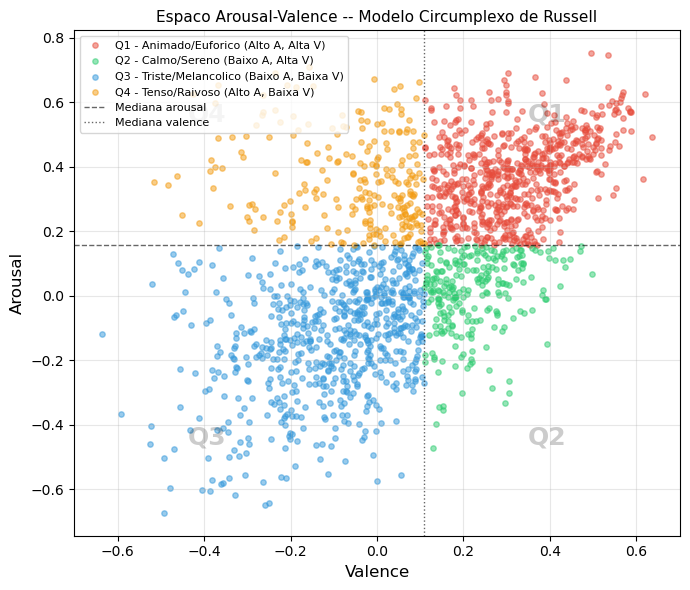

In [4]:
colors     = {'Q1':'#e74c3c', 'Q2':'#2ecc71', 'Q3':'#3498db', 'Q4':'#f39c12'}
labels_map = {
    'Q1': 'Q1 - Animado/Euforico (Alto A, Alta V)',
    'Q2': 'Q2 - Calmo/Sereno (Baixo A, Alta V)',
    'Q3': 'Q3 - Triste/Melancolico (Baixo A, Baixa V)',
    'Q4': 'Q4 - Tenso/Raivoso (Alto A, Baixa V)',
}
fig, ax = plt.subplots(figsize=(7, 6))
for q, grp in df_emotions.groupby('quadrante'):
    ax.scatter(grp['valence_mean'], grp['arousal_mean'],
               c=colors[q], label=labels_map[q], alpha=0.5, s=15)
ax.axhline(mediana_a, color='k', lw=1, ls='--', alpha=0.6, label='Mediana arousal')
ax.axvline(mediana_v, color='k', lw=1, ls=':',  alpha=0.6, label='Mediana valence')
for txt, xy in [('Q1',(0.78,0.82)),('Q2',(0.78,0.18)),
                ('Q3',(0.22,0.18)),('Q4',(0.22,0.82))]:
    ax.text(*xy, txt, transform=ax.transAxes, fontsize=18,
            fontweight='bold', alpha=0.2, ha='center')
ax.set_xlabel('Valence', fontsize=12)
ax.set_ylabel('Arousal', fontsize=12)
ax.set_title('Espaco Arousal-Valence -- Modelo Circumplexo de Russell', fontsize=11)
ax.legend(fontsize=8, loc='upper left')
ax.grid(True, alpha=0.3)
plt.tight_layout()
if SAVE_FIGURES: plt.savefig(f'{FIG_DIR}/circumplex_scatter.png', dpi=200, bbox_inches='tight')
plt.show()


In [5]:
# Contagem absoluta
contagem_quadrantes = df_emotions['quadrante'].value_counts().sort_index()

print("Quantidade de amostras por quadrante:")
print(contagem_quadrantes)

Quantidade de amostras por quadrante:
quadrante
Q1    654
Q2    247
Q3    654
Q4    247
Name: count, dtype: int64


## 4. Pre-processamento e Extracao de Features Espectrais

### Janela de Hann -- eq. (1) do artigo
$$w[n] = 0{,}5\left(1 - \cos\left(\frac{2\pi n}{L-1}\right)\right), \quad 0 \le n \le L-1$$
com $L = 2048$ amostras $\approx 46{,}4$ ms a 44100 Hz.

### DFT por quadro -- eq. (2) do artigo
$$X_k[m] = \sum_{n=0}^{L-1} x_k[n]\,w[n]\,e^{-j2\pi mn/L}$$

### PSD media de Welch -- eq. (3) do artigo
$$\overline{\mathrm{PSD}}[m] = \frac{1}{K}\sum_{k=1}^{K}\frac{1}{LU}|X_k[m]|^2, \quad U=\frac{1}{L}\sum_{n=0}^{L-1}|w[n]|^2$$

### Descritores (eqs. 4-7 do artigo)
1. **Centroide espectral** eq.(4): $C = \sum f[m]\overline{\mathrm{PSD}}[m] / \sum \overline{\mathrm{PSD}}[m]$
2. **Largura de banda** eq.(5): $B = \sqrt{\sum (f[m]-C)^2\overline{\mathrm{PSD}}[m]/\sum\overline{\mathrm{PSD}}[m]}$
3. **Roll-off** $f_r$: frequencia abaixo da qual concentra 85% da energia (Secao 2.3)
4. **ZCR** eq.(7): $\mathrm{ZCR} = \frac{1}{N-1}\sum \mathbb{I}\{\mathrm{sgn}(x[n])\neq\mathrm{sgn}(x[n-1])\}$
5. **Energia RMS**


In [6]:
SR      = 22050   # taxa de amostragem (Hz)
L       = 2048    # tamanho da janela -- ~46,4 ms a 44100 Hz (Secao 2.2)
HOP     = L // 2  # sobreposicao 50%
ROLLOFF = 0.85    # 85% da energia espectral (Secao 2.3)

def hann_window(L):
    """Janela de Hann -- eq. (1) do artigo."""
    n = np.arange(L)
    return 0.5 * (1.0 - np.cos(2.0 * np.pi * n / (L - 1)))

def compute_welch_psd(x, sr, L=L):
    """PSD media pelo metodo de Welch com janela de Hann -- eq. (3) do artigo."""
    w = hann_window(L)
    f_arr, Pxx = signal.welch(x, fs=sr, window=w, nperseg=L,
                              noverlap=L // 2, scaling='density')
    return f_arr, Pxx

def extract_features(x, sr, L=L):
    """
    Extrai os 5 descritores espectrais/energeticos (Secao 2.3 do artigo).
    Retorna dict: spectral_centroid, spectral_bandwidth,
                  spectral_rolloff, zcr, rms_energy
    """
    # Normalizacao RMS (Secao 2.2)
    rms_global = np.sqrt(np.mean(x ** 2)) + 1e-12
    x_norm = x / rms_global

    f_arr, Pxx = compute_welch_psd(x_norm, sr, L)
    eps = 1e-20

    # eq. (4) -- Centroide espectral
    centroid  = np.sum(f_arr * Pxx) / (np.sum(Pxx) + eps)

    # eq. (5) -- Largura de banda
    bandwidth = np.sqrt(np.sum((f_arr - centroid) ** 2 * Pxx) /
                        (np.sum(Pxx) + eps))

    # Roll-off 85% -- Secao 2.3
    cumE        = np.cumsum(Pxx)
    idx_r       = np.searchsorted(cumE, ROLLOFF * cumE[-1])
    rolloff_hz  = f_arr[min(idx_r, len(f_arr) - 1)]

    # eq. (7) -- ZCR
    zcr = float(np.mean(librosa.feature.zero_crossing_rate(
        x_norm, frame_length=L, hop_length=HOP)))

    # Energia RMS
    rms_energy = float(np.mean(librosa.feature.rms(
        y=x_norm, frame_length=L, hop_length=HOP)))

    return dict(spectral_centroid=centroid,
                spectral_bandwidth=bandwidth,
                spectral_rolloff=rolloff_hz,
                zcr=zcr,
                rms_energy=rms_energy)

print(f'Funcoes definidas. L={L}, hop={HOP}, roll-off={int(ROLLOFF*100)}%')


Funcoes definidas. L=2048, hop=1024, roll-off=85%


## 5. Extracao de Features das Musicas do DEAM

> Itera sobre os arquivos `.mp3`, aplica pre-processamento e extrai os 5 descritores.  
> **Se voce ja possui o CSV**, pule para o bloco alternativo abaixo.


In [ ]:
audio_files = sorted([f for f in os.listdir(PATH_AUDIO) if f.endswith('.mp3')])
print(f'{len(audio_files)} arquivos .mp3 encontrados.')

valid_ids = set(df_emotions['song_id'].values)
records   = []

for fname in tqdm(audio_files, desc='Extraindo features'):
    try:
        song_id = int(os.path.splitext(fname)[0])
        if song_id not in valid_ids:
            continue
        y, sr = librosa.load(os.path.join(PATH_AUDIO, fname), sr=SR, mono=True)
        feats = extract_features(y, sr)
        feats['song_id'] = song_id
        records.append(feats)
    except Exception as e:
        print(f'  ERRO em {fname}: {e}')

df_features = pd.DataFrame(records)
df_features.to_csv('features_extraidas.csv', index=False)
print(f'{len(df_features)} faixas processadas. Salvo em features_extraidas.csv')


1802 arquivos .mp3 encontrados.


Extraindo features:   0%|          | 0/1802 [00:00<?, ?it/s]

### Alternativa: carregar CSV de features pre-extraidas


In [ ]:
# Execute ESTE bloco se ja tem o CSV:
df_features = pd.read_csv(PATH_FEATURES)
print(df_features.shape, df_features.head())


## 6. Construcao do Dataset Final


In [ ]:
FEATURES = ['spectral_centroid', 'spectral_bandwidth',
            'spectral_rolloff', 'zcr', 'rms_energy']

dataset = pd.merge(
    df_features[['song_id'] + FEATURES],
    df_emotions[['song_id', 'arousal_mean', 'valence_mean', 'quadrante']],
    on='song_id'
).dropna()

# Grupos por quadrante
QUAD_ORDER = ['Q1', 'Q2', 'Q3', 'Q4']
groups = {q: dataset[dataset['quadrante'] == q] for q in QUAD_ORDER}

print('Dataset final:')
print(dataset['quadrante'].value_counts().sort_index())
print(f'Total: {len(dataset)} amostras  |  Features: {FEATURES}')

describe_table = dataset[FEATURES].describe().round(4)
display(describe_table)

if SAVE_FIGURES:
    salvar_tabela_como_imagem(
        describe_table, f'{FIG_DIR}/tabela_describe_features.png',
        titulo='Estatisticas Descritivas das Features'
    )


## 7. Analise Estatistica: Kruskal-Wallis

Teste nao-parametrico para multiplos grupos -- extensao do Mann-Whitney.  
O artigo confirma **p < 10^{-30}** para todos os descritores.

### Tamanho de efeito eta2 -- eq. (8) do artigo
$$\eta^2 = \frac{H - (k-1)}{n - k}$$
com $k=4$, $n$ = total de amostras. Resultados esperados: centroide eta2=0,42; roll-off eta2=0,40.


In [ ]:
n_total = len(dataset)
k_groups = 4

print(f"{'Feature':<25} {'H':>10} {'p-value':>14} {'eta2':>8}")
print('-' * 62)

kw_results = {}
rows_kw = []
for feat in FEATURES:
    samples = [groups[q][feat].values for q in QUAD_ORDER]
    H, p    = kruskal(*samples)
    eta2    = max((H - (k_groups - 1)) / (n_total - k_groups), 0)  # eq. (8)
    kw_results[feat] = {'H': H, 'p': p, 'eta2': eta2}
    print(f"{feat:<25} {H:>10.2f} {p:>14.2e} {eta2:>8.4f}")
    rows_kw.append({'Feature': feat, 'H': round(H, 2), 'p-value': f'{p:.2e}', 'eta2': round(eta2, 4)})

kw_table = pd.DataFrame(rows_kw).set_index('Feature')
display(kw_table)

if SAVE_FIGURES:
    salvar_tabela_como_imagem(
        kw_table, f'{FIG_DIR}/tabela_kruskal_wallis.png',
        titulo='Teste de Kruskal-Wallis por Feature'
    )


### Post-hoc de Dunn com Correcao de Bonferroni

Identifica quais pares de quadrantes diferem significativamente.  
O artigo indica que comparacoes no eixo de *arousal* (Q1 vs Q4, Q2 vs Q3)
produzem p-valores menores que as comparacoes diagonais.


In [ ]:
feat_highlight = 'spectral_centroid'   # feature de maior eta2

data_dunn = dataset[['quadrante', feat_highlight]].rename(
    columns={'quadrante': 'group', feat_highlight: 'value'})

pvals_dunn = sp.posthoc_dunn(
    data_dunn, val_col='value', group_col='group', p_adjust='bonferroni'
)
print(f'p-valores post-hoc de Dunn (Bonferroni) -- {feat_highlight}:')
pvals_dunn_round = pvals_dunn.round(4)
display(pvals_dunn_round)

if SAVE_FIGURES:
    salvar_tabela_como_imagem(
        pvals_dunn_round, f'{FIG_DIR}/tabela_dunn_posthoc.png',
        titulo=f'Post-hoc de Dunn (Bonferroni) -- {feat_highlight}'
    )

fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(pvals_dunn.values, cmap='RdYlGn_r', vmin=0, vmax=0.05)
qs = pvals_dunn.columns.tolist()
ax.set_xticks(range(len(qs))); ax.set_xticklabels(qs)
ax.set_yticks(range(len(qs))); ax.set_yticklabels(qs)
plt.colorbar(im, ax=ax, label='p-valor (Bonferroni)')
ax.set_title(f'Post-hoc de Dunn -- {feat_highlight}', fontsize=10)
for i in range(len(qs)):
    for j in range(len(qs)):
        v = pvals_dunn.values[i, j]
        ax.text(j, i, f'{v:.3f}', ha='center', va='center', fontsize=8,
                color='white' if v < 0.025 else 'black')
plt.tight_layout()
if SAVE_FIGURES: plt.savefig(f'{FIG_DIR}/dunn_posthoc.png', dpi=200, bbox_inches='tight')
plt.show()


## 8. Histogramas das Features por Quadrante -- Fig. 2 do artigo

> *Histogramas das features por quadrante (Q1-Q4), evidenciando o escalonamento dos*
> *descritores espectrais ao longo dos eixos de arousal e valence.*


In [ ]:
feat_labels = {
    'spectral_centroid'  : 'Centroide Espectral (Hz)',
    'spectral_bandwidth' : 'Largura de Banda (Hz)',
    'spectral_rolloff'   : 'Roll-off (Hz)',
    'zcr'                : 'Taxa de Cruzamentos por Zero (ZCR)',
    'rms_energy'         : 'Energia RMS',
}
quad_colors = {'Q1':'#e74c3c', 'Q2':'#2ecc71', 'Q3':'#3498db', 'Q4':'#f39c12'}

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, feat in enumerate(FEATURES):
    ax = axes[i]
    for q in QUAD_ORDER:
        ax.hist(groups[q][feat].values, bins=40, alpha=0.55,
                color=quad_colors[q], label=q, density=True, edgecolor='none')
    ax.set_xlabel(feat_labels[feat], fontsize=9)
    ax.set_ylabel('Densidade', fontsize=9)
    ax.set_title(feat_labels[feat], fontsize=10, fontweight='bold')
    eta2_v = kw_results[feat]['eta2']
    ax.text(0.97, 0.95, f'eta2={eta2_v:.3f}\np<1e-30',
            transform=ax.transAxes, ha='right', va='top', fontsize=7,
            bbox=dict(boxstyle='round,pad=0.2', fc='white', alpha=0.8))
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

fig.delaxes(axes[-1])
plt.suptitle('Histogramas das Features por Quadrante Q1-Q4', fontsize=13, fontweight='bold')
plt.tight_layout()
if SAVE_FIGURES: plt.savefig(f'{FIG_DIR}/histogramas.png', dpi=200, bbox_inches='tight')
plt.show()


### Boxplots por Quadrante


In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

for i, feat in enumerate(FEATURES):
    ax = axes[i]
    data_bp = [groups[q][feat].values for q in QUAD_ORDER]
    bp = ax.boxplot(data_bp, labels=QUAD_ORDER, patch_artist=True, notch=True)
    for patch, q in zip(bp['boxes'], QUAD_ORDER):
        patch.set_facecolor(quad_colors[q])
        patch.set_alpha(0.7)
    ax.set_title(feat_labels[feat], fontsize=10)
    ax.set_ylabel(feat_labels[feat], fontsize=8)
    ax.grid(True, alpha=0.3, axis='y')

fig.delaxes(axes[-1])
plt.suptitle('Boxplots das Features por Quadrante Q1-Q4', fontsize=13, fontweight='bold')
plt.tight_layout()
if SAVE_FIGURES: plt.savefig(f'{FIG_DIR}/boxplots.png', dpi=200, bbox_inches='tight')
plt.show()


## 8.5. Visualização do Espaço de Características

> *Projeção bidimensional das features utilizando PCA para visualizar a separabilidade das classes.*

In [ ]:
# PCA para 2 componentes principais
pca = PCA(n_components=2)
X_pca = pca.fit_transform(dataset[FEATURES].values)
y_labels = dataset['quadrante'].values

# Variancia explicada
var_exp = pca.explained_variance_ratio_
var_acum = np.cumsum(var_exp)

print(f"PC1 explica {var_exp[0]*100:.2f}% da variancia")
print(f"PC2 explica {var_exp[1]*100:.2f}% da variancia")
print(f"Variancia acumulada (PC1 + PC2): {var_acum[1]*100:.2f}%")

plt.figure(figsize=(10, 8))
sns.scatterplot(
    x=X_pca[:, 0],
    y=X_pca[:, 1],
    hue=y_labels,
    palette=colors,
    s=80,
    alpha=0.7,
    hue_order=QUAD_ORDER
)

plt.title(
    f'Espaco de Caracteristicas (PCA 2D)\n'
    f'Variancia acumulada: {var_acum[1]*100:.1f}%'
)

plt.xlabel(f'Componente Principal 1 ({var_exp[0]*100:.1f}%)')
plt.ylabel(f'Componente Principal 2 ({var_exp[1]*100:.1f}%)')
plt.legend(title='Quadrante')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()

# Salvar a imagem (mesma pasta das demais figuras, FIG_DIR)
img_filename = 'pca_espaco_caracteristicas.png'
img_path = f'{FIG_DIR}/{img_filename}'
if SAVE_FIGURES:
    plt.savefig(img_path, dpi=200, bbox_inches='tight')
plt.show()

# Gerar arquivo .txt com a secao em LaTeX
latex_content = rf"""
\section{{Visualizacao do Espaco de Caracteristicas}}

Para analisar a separabilidade das classes no espaco de caracteristicas espectrais extraidas, aplicou-se a Analise de Componentes Principais (PCA), reduzindo a dimensionalidade para duas componentes. A primeira componente principal explicou {var_exp[0]*100:.2f}\% da variancia total dos dados, enquanto a segunda explicou {var_exp[1]*100:.2f}\%, resultando em uma variancia acumulada de {var_acum[1]*100:.2f}\%.

A Figura \ref{{fig:pca_features}} apresenta a projecao bidimensional das amostras no espaco das duas componentes principais, permitindo avaliar visualmente a distribuicao e a sobreposicao entre os quadrantes emocionais.

\begin{{figure}}[htpb]
    \centering
    \includegraphics[width=0.8\textwidth]{{{FIG_DIR}/{img_filename}}}
    \caption{{Projecao bidimensional do espaco de caracteristicas utilizando PCA. As duas componentes principais retem {var_acum[1]*100:.2f}\% da variancia total dos dados.}}
    \label{{fig:pca_features}}
\end{{figure}}
"""

txt_path = f'{FIG_DIR}/resultados_espaco_caracteristicas.txt'
with open(txt_path, 'w', encoding='utf-8') as f:
    f.write(latex_content)

print(f"Imagem '{img_path}' e arquivo '{txt_path}' gerados com sucesso!")


## 9. PSD Media por Quadrante -- Metodo de Welch -- Fig. 3 do artigo

> *PSD media (metodo de Welch) por quadrante Q1-Q4, evidenciando maior potencia espectral*
> *nos grupos de alto arousal (Q1 e Q4).*

Implementacao das eqs. (1)-(3) do artigo: janela de Hann, L=2048, sobreposicao 50%.


In [ ]:
psd_by_quad  = {q: [] for q in QUAD_ORDER}
ids_by_quad  = {q: set(groups[q]['song_id'].values) for q in QUAD_ORDER}
audio_files  = sorted([f for f in os.listdir(PATH_AUDIO) if f.endswith('.mp3')])

f_ref = None
for fname in tqdm(audio_files, desc='Calculando PSD'):
    try:
        song_id = int(os.path.splitext(fname)[0])
        q_label = next((q for q in QUAD_ORDER if song_id in ids_by_quad[q]), None)
        if q_label is None:
            continue
        y, sr = librosa.load(os.path.join(PATH_AUDIO, fname), sr=SR, mono=True)
        rms = np.sqrt(np.mean(y**2)) + 1e-12
        f_arr, Pxx = compute_welch_psd(y / rms, sr)
        psd_by_quad[q_label].append(Pxx)
        if f_ref is None:
            f_ref = f_arr
    except Exception:
        pass

# Plot PSD media
psd_styles = {
    'Q1': ('Q1 - Alto A, Alta V (Animado)',  '#e74c3c', '-'),
    'Q2': ('Q2 - Baixo A, Alta V (Calmo)',   '#2ecc71', '--'),
    'Q3': ('Q3 - Baixo A, Baixa V (Triste)', '#3498db', ':'),
    'Q4': ('Q4 - Alto A, Baixa V (Tenso)',   '#f39c12', '-.'),
}

fig, ax = plt.subplots(figsize=(10, 5))
for q in QUAD_ORDER:
    if psd_by_quad[q] and f_ref is not None:
        mean_psd = np.mean(psd_by_quad[q], axis=0)
        lbl, clr, ls = psd_styles[q]
        ax.plot(f_ref, 10 * np.log10(mean_psd + 1e-20),
                label=lbl, color=clr, ls=ls, lw=1.8, alpha=0.9)

ax.set_xlabel('Frequencia (Hz)', fontsize=11)
ax.set_ylabel('PSD (dB/Hz)', fontsize=11)
ax.set_title('PSD Media por Quadrante Q1-Q4 -- Metodo de Welch (Janela de Hann, L=2048)', fontsize=11)
ax.set_xscale('log')
ax.xaxis.set_major_formatter(ticker.ScalarFormatter())
ax.set_xlim([20, SR // 2])
ax.legend(fontsize=9)
ax.grid(True, which='both', alpha=0.3)
plt.tight_layout()
if SAVE_FIGURES: plt.savefig(f'{FIG_DIR}/PSD.png', dpi=200, bbox_inches='tight')
plt.show()


## 10. Classificador Random Forest -- Validacao Cruzada Estratificada k=5

Configuracao exata do artigo (Secao 2.4):
- Vetor de features $\mathbf{f}_i \in \mathbb{R}^5$
- `RandomForestClassifier(n_estimators=100)`
- Validacao cruzada estratificada $k=5$
- Metricas reportadas como medias +- desvios-padrao

Metricas -- eqs. do artigo:
$$\text{Acc} = \sum_c (TP_c + TN_c)/n \qquad \text{F1}_c = 2\cdot\frac{P_c \cdot R_c}{P_c + R_c}$$


In [ ]:
X_data = dataset[FEATURES].values
le     = LabelEncoder()
y_data = le.fit_transform(dataset['quadrante'])  # Q1->0, Q2->1, Q3->2, Q4->3
class_names = le.classes_

rf  = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scoring = {
    'accuracy'        : 'accuracy',
    'f1_macro'        : 'f1_macro',
    'precision_macro' : 'precision_macro',
    'recall_macro'    : 'recall_macro',
}

cv_results = cross_validate(rf, X_data, y_data, cv=skf,
                            scoring=scoring, return_train_score=False)

print('Resultados -- Validacao Cruzada Estratificada (k=5):')
print(f'  Acuracia : {cv_results["test_accuracy"].mean()*100:.1f}% +- {cv_results["test_accuracy"].std()*100:.1f}%')
print(f'  F1-macro : {cv_results["test_f1_macro"].mean():.3f} +- {cv_results["test_f1_macro"].std():.3f}')
print(f'  Precisao : {cv_results["test_precision_macro"].mean():.3f} +- {cv_results["test_precision_macro"].std():.3f}')
print(f'  Recall   : {cv_results["test_recall_macro"].mean():.3f} +- {cv_results["test_recall_macro"].std():.3f}')
print(f'\n  Baseline aleatorio (4 classes): 25.0%')


### Metricas por Quadrante (Tabela 2 do artigo)


In [ ]:
y_pred_cv = cross_val_predict(rf, X_data, y_data, cv=skf)
report    = classification_report(y_data, y_pred_cv,
                                   target_names=class_names, output_dict=True)

q_long = {
    'Q1': 'Q1 (Alto A, Alta V)',
    'Q2': 'Q2 (Baixo A, Alta V)',
    'Q3': 'Q3 (Baixo A, Baixa V)',
    'Q4': 'Q4 (Alto A, Baixa V)',
}

print(f"{'Quadrante':<25} {'Precisao':>10} {'Recall':>8} {'F1':>8}")
print('-' * 56)
rows_metrics = []
for q in class_names:
    p  = report[q]['precision'] * 100
    r  = report[q]['recall']    * 100
    f1 = report[q]['f1-score']  * 100
    print(f"{q_long[q]:<25} {p:>9.1f}%  {r:>7.1f}%  {f1:>7.1f}%")
    rows_metrics.append({
        'Quadrante': q_long[q],
        'Precisao (%)': round(p, 1),
        'Recall (%)': round(r, 1),
        'F1 (%)': round(f1, 1),
    })
print('-' * 56)
acc_v = cv_results['test_accuracy'].mean() * 100
f1_v  = cv_results['test_f1_macro'].mean()
print(f"Acuracia global: {acc_v:.1f}%  |  F1-macro: {f1_v:.3f}")

metricas_quadrante_table = pd.DataFrame(rows_metrics).set_index('Quadrante')
display(metricas_quadrante_table)

if SAVE_FIGURES:
    salvar_tabela_como_imagem(
        metricas_quadrante_table, f'{FIG_DIR}/tabela_metricas_por_quadrante.png',
        titulo='Metricas por Quadrante (Tabela 2 do artigo)'
    )


### Matriz de Confusao 4x4 (percentual) -- Fig. 4 do artigo

> *Matriz de confusao 4x4 do classificador Random Forest (valores percentuais)*
> *para os quadrantes Q1-Q4.*


In [ ]:
cm = confusion_matrix(y_data, y_pred_cv, normalize='true') * 100

fig, ax = plt.subplots(figsize=(7, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(cmap='Blues', values_format='.1f', ax=ax, colorbar=False)
for text_obj in disp.text_.ravel():
    text_obj.set_text(text_obj.get_text() + '%')
    text_obj.set_fontsize(11)
ax.set_xlabel('Predito', fontsize=11)
ax.set_ylabel('Real', fontsize=11)
ax.set_title('Matriz de Confusao 4x4 -- Random Forest (CV k=5)', fontsize=11)
plt.tight_layout()
if SAVE_FIGURES: plt.savefig(f'{FIG_DIR}/matriz_confusao.png', dpi=200, bbox_inches='tight')
plt.show()


### Importancia das Features -- Reducao de Impureza de Gini -- Fig. 5 do artigo

> *Importancia relativa das features (reducao de impureza de Gini) no modelo Random Forest*
> *para classificacao em Q1-Q4.*

O artigo indica que **centroide espectral** e **roll-off** dominam a classificacao (eixo arousal).


In [ ]:
rf.fit(X_data, y_data)   # treino completo para importancias
importances = rf.feature_importances_

label_map = {
    'spectral_centroid'  : 'Centroide Espectral',
    'spectral_bandwidth' : 'Largura de Banda',
    'spectral_rolloff'   : 'Roll-off (85%)',
    'zcr'                : 'ZCR',
    'rms_energy'         : 'Energia RMS',
}

feat_imp = pd.Series(importances, index=FEATURES).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(7, 4))
clrs = ['#e74c3c' if v >= 0.22 else '#3498db' for v in feat_imp]
bars = ax.barh([label_map[f] for f in feat_imp.index], feat_imp.values,
               color=clrs, edgecolor='white', height=0.6)
ax.bar_label(bars, fmt='%.3f', padding=3, fontsize=9)
ax.set_xlabel('Importancia (Impureza de Gini)', fontsize=11)
ax.set_title('Importancia Relativa das Features -- Random Forest (Q1-Q4)', fontsize=11)
ax.set_xlim([0, feat_imp.max() * 1.20])
ax.grid(True, axis='x', alpha=0.4)
plt.tight_layout()
if SAVE_FIGURES: plt.savefig(f'{FIG_DIR}/importancia_features.png', dpi=200, bbox_inches='tight')
plt.show()

print('Importancias (Gini):')
for feat, imp in feat_imp.sort_values(ascending=False).items():
    print(f'  {label_map[feat]:<22}: {imp:.4f}')


## 11. Resumo dos Resultados (Tabela 2 do artigo)


In [ ]:
print('=' * 62)
print('RESUMO -- CLASSIFICADOR RANDOM FOREST (n_estimators=100)')
print('Validacao cruzada estratificada k=5')
print('=' * 62)
print(f'  Acuracia global : {cv_results["test_accuracy"].mean()*100:.1f}% +- '
      f'{cv_results["test_accuracy"].std()*100:.1f}%')
print(f'  F1-macro        : {cv_results["test_f1_macro"].mean():.3f} +- '
      f'{cv_results["test_f1_macro"].std():.3f}')
print()
print(f"  {'Quadrante':<25} {'P':>6} {'R':>6} {'F1':>6}")
print('  ' + '-' * 44)
rows_resumo = []
for q in class_names:
    p  = report[q]['precision'] * 100
    r  = report[q]['recall']    * 100
    f1 = report[q]['f1-score']  * 100
    print(f'  {q_long[q]:<25} {p:>5.1f}% {r:>5.1f}% {f1:>5.1f}%')
    rows_resumo.append({'Quadrante': q_long[q], 'P (%)': round(p, 1),
                         'R (%)': round(r, 1), 'F1 (%)': round(f1, 1)})
print()
melhora = cv_results['test_accuracy'].mean()*100 - 25.0
print(f'  Baseline aleatorio (4 classes): 25.0%')
print(f'  Melhoria sobre baseline       : +{melhora:.1f}%')
print('=' * 62)

resumo_table = pd.DataFrame(rows_resumo).set_index('Quadrante')
resumo_table.loc['Global'] = [
    round(cv_results['test_accuracy'].mean()*100, 1),
    round(cv_results['test_recall_macro'].mean()*100, 1),
    round(cv_results['test_f1_macro'].mean()*100, 1),
]
display(resumo_table)

titulo_resumo = (
    f"Resumo dos Resultados -- Acuracia: {acc_v:.1f}% | F1-macro: {f1_v:.3f}\n"
    f"Melhoria sobre baseline aleatorio (25.0%): +{melhora:.1f}%"
)

if SAVE_FIGURES:
    salvar_tabela_como_imagem(
        resumo_table, f'{FIG_DIR}/tabela_resumo_resultados.png',
        titulo=titulo_resumo
    )
